In [1]:
from ax.service.ax_client import AxClient
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

In [2]:
ax_client_file_path = "/Users/zeqing/0_Github/drug_surfactant/experiments/20250623/iteration_4/optimizer/optimizer_4_loaded.json"

In [3]:
ax_client = AxClient.load_from_json_file(ax_client_file_path)


[INFO 06-24 09:08:35] ax.service.ax_client: Starting optimization with verbose logging. To disable logging, set the `verbose_logging` argument to `False`. Note that float values in the logs are rounded to 6 decimal points.


In [4]:
df = ax_client.get_trials_data_frame()

In [5]:
df

,trial_index,arm_name,trial_status,generation_method,generation_node,micelle_drug_conc,success,initial_drug_conc_surfactant_conc_ratio,complexity,Drug_MW,...,s1,s2,s3,s4,s5,s6,s7,s8,surfactant_conc,drug_conc
0,0,0_0,COMPLETED,Sobol,GenerationStep_0,0.00,0.0,0.004477,1.000,0.206,...,48,59,50,31,96,8,9,35,86,77
1,1,1_0,COMPLETED,Sobol,GenerationStep_0,0.00,0.0,0.000429,1.000,0.206,...,95,22,75,63,43,72,55,100,35,3
2,2,2_0,COMPLETED,Sobol,GenerationStep_0,0.00,0.0,0.008889,1.000,0.206,...,53,98,4,13,22,90,29,56,18,32
3,3,3_0,COMPLETED,Sobol,GenerationStep_0,0.58,1.0,0.004265,1.000,0.206,...,6,33,71,83,63,26,87,16,68,58
4,4,4_0,COMPLETED,Sobol,GenerationStep_0,0.00,0.0,0.125000,1.000,0.206,...,24,86,97,98,58,17,48,64,1,25
5,5,5_0,COMPLETED,Sobol,GenerationStep_0,0.99,1.0,0.009706,1.000,0.206,...,72,45,29,4,5,53,93,2,51,99
6,6,6_0,COMPLETED,SAASBO,GenerationStep_1,0.00,0.0,0.500000,0.250,0.206,...,0,0,0,100,0,0,100,0,1,100
7,7,7_0,COMPLETED,SAASBO,GenerationStep_1,0.00,0.0,0.500000,0.250,0.206,...,0,0,100,0,0,0,100,0,1,100
8,8,8_0,COMPLETED,SAASBO,GenerationStep_1,0.00,0.0,0.005000,0.750,0.206,...,100,100,100,100,0,100,100,0,100,100
9,9,9_0,COMPLETED,SAASBO,GenerationStep_1,0.00,0.0,0.500000,0.375,0.206,...,100,0,0,100,0,0,100,0,1,100


In [8]:
batch_size = 6

In [9]:

batch_size = 6
num_batches = len(df)/batch_size  # how many different numbers you want

iteration_array = np.repeat(np.arange(num_batches), batch_size)
iteration_array

array([0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 2., 2., 2., 2., 2.,
       2., 3., 3., 3., 3., 3., 3., 4., 4., 4., 4., 4., 4.])

In [10]:
df['Iteration'] = iteration_array
df

,trial_index,arm_name,trial_status,generation_method,generation_node,micelle_drug_conc,success,initial_drug_conc_surfactant_conc_ratio,complexity,Drug_MW,...,s2,s3,s4,s5,s6,s7,s8,surfactant_conc,drug_conc,Iteration
0,0,0_0,COMPLETED,Sobol,GenerationStep_0,0.00,0.0,0.004477,1.000,0.206,...,59,50,31,96,8,9,35,86,77,0.0
1,1,1_0,COMPLETED,Sobol,GenerationStep_0,0.00,0.0,0.000429,1.000,0.206,...,22,75,63,43,72,55,100,35,3,0.0
2,2,2_0,COMPLETED,Sobol,GenerationStep_0,0.00,0.0,0.008889,1.000,0.206,...,98,4,13,22,90,29,56,18,32,0.0
3,3,3_0,COMPLETED,Sobol,GenerationStep_0,0.58,1.0,0.004265,1.000,0.206,...,33,71,83,63,26,87,16,68,58,0.0
4,4,4_0,COMPLETED,Sobol,GenerationStep_0,0.00,0.0,0.125000,1.000,0.206,...,86,97,98,58,17,48,64,1,25,0.0
5,5,5_0,COMPLETED,Sobol,GenerationStep_0,0.99,1.0,0.009706,1.000,0.206,...,45,29,4,5,53,93,2,51,99,0.0
6,6,6_0,COMPLETED,SAASBO,GenerationStep_1,0.00,0.0,0.500000,0.250,0.206,...,0,0,100,0,0,100,0,1,100,1.0
7,7,7_0,COMPLETED,SAASBO,GenerationStep_1,0.00,0.0,0.500000,0.250,0.206,...,0,100,0,0,0,100,0,1,100,1.0
8,8,8_0,COMPLETED,SAASBO,GenerationStep_1,0.00,0.0,0.005000,0.750,0.206,...,100,100,100,0,100,100,0,100,100,1.0
9,9,9_0,COMPLETED,SAASBO,GenerationStep_1,0.00,0.0,0.500000,0.375,0.206,...,0,0,100,0,0,100,0,1,100,1.0


In [11]:
params = ['s1', 's2', 's3', 's4', 's5', 's6', 's7', 's8', 'surfactant_conc', 'drug_conc']

objs = ['complexity', 'initial_drug_conc_surfactant_conc_ratio', 'success', 'micelle_drug_conc']

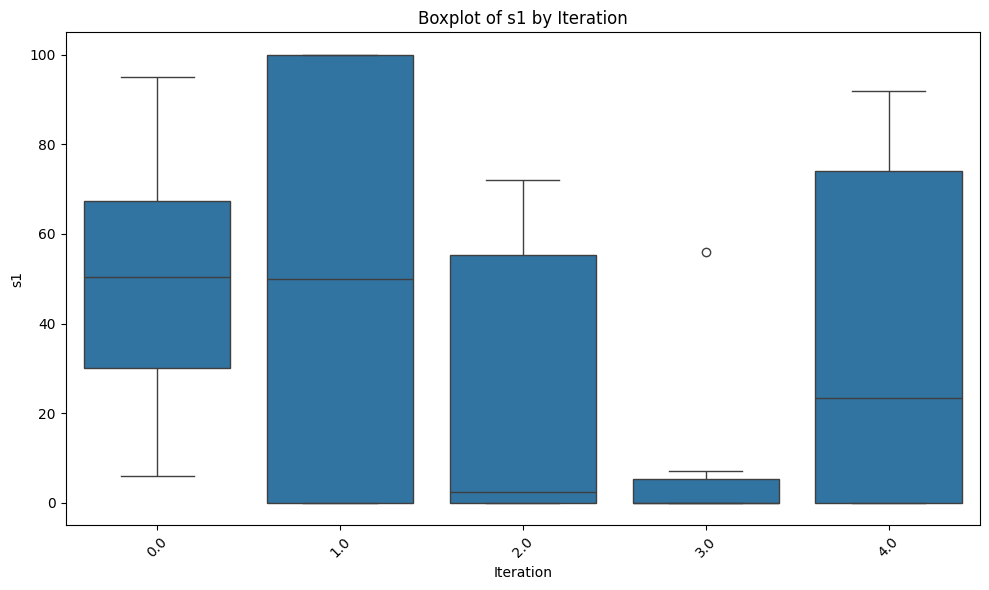

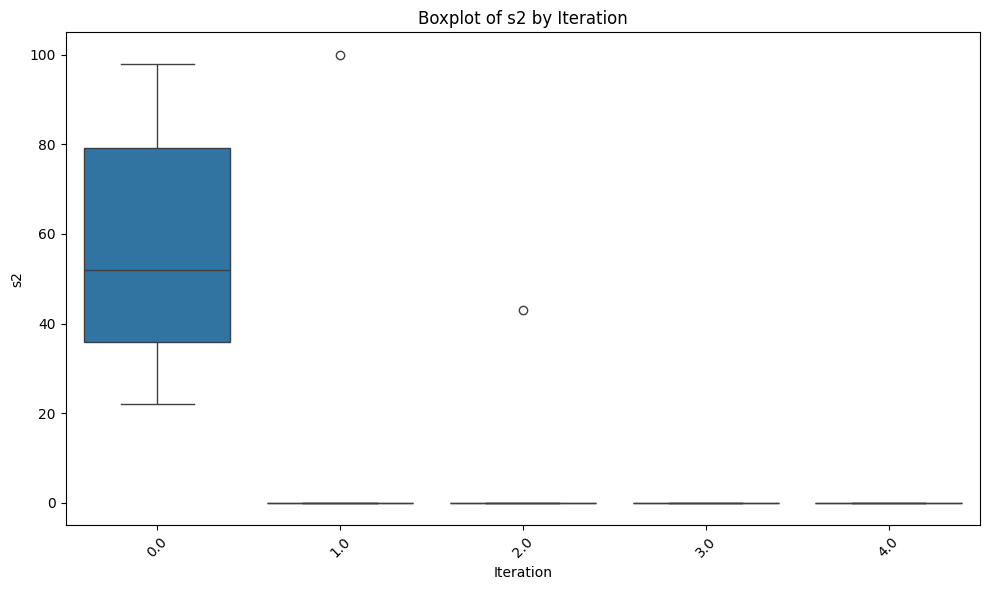

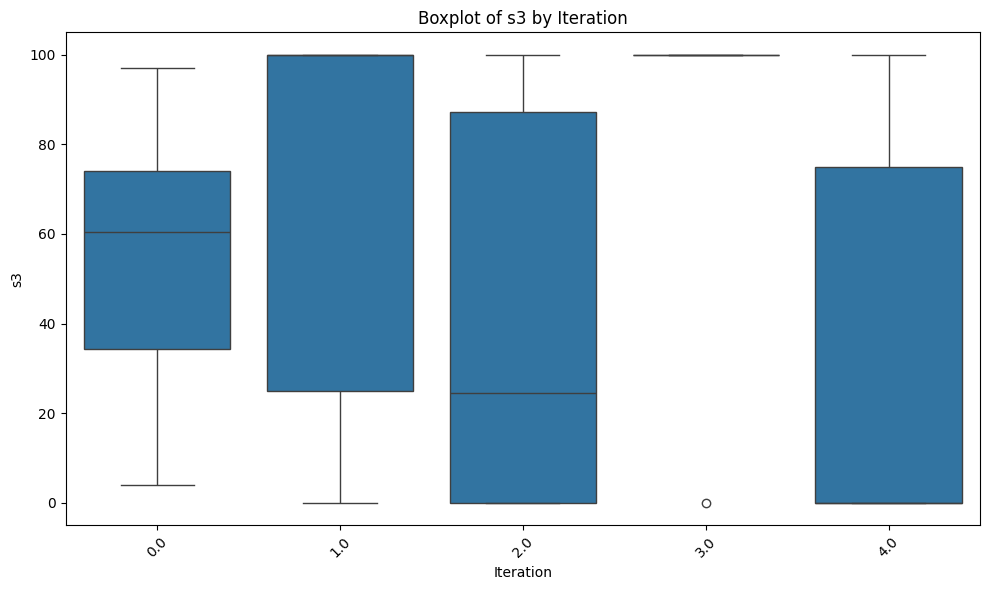

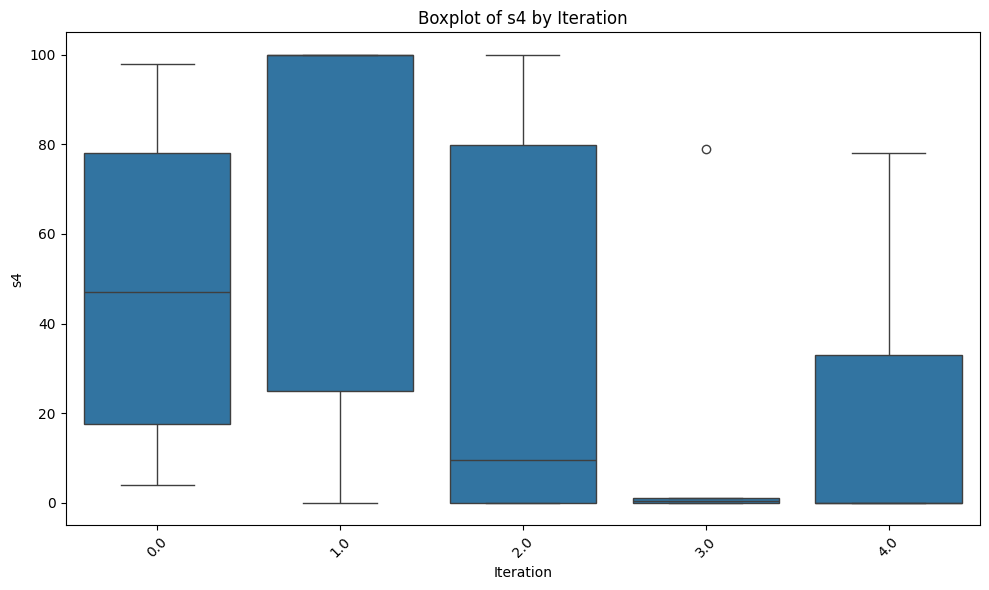

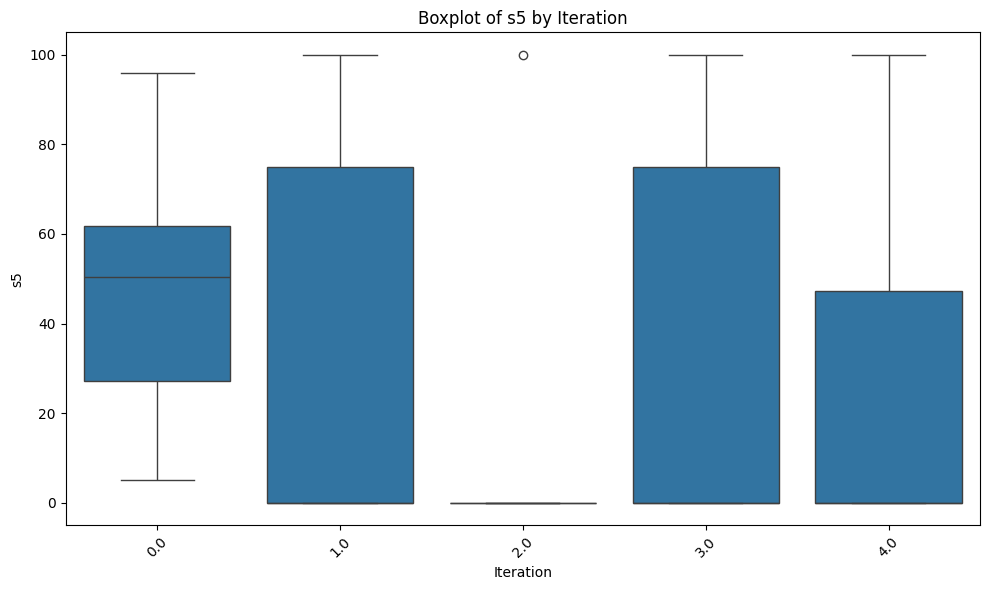

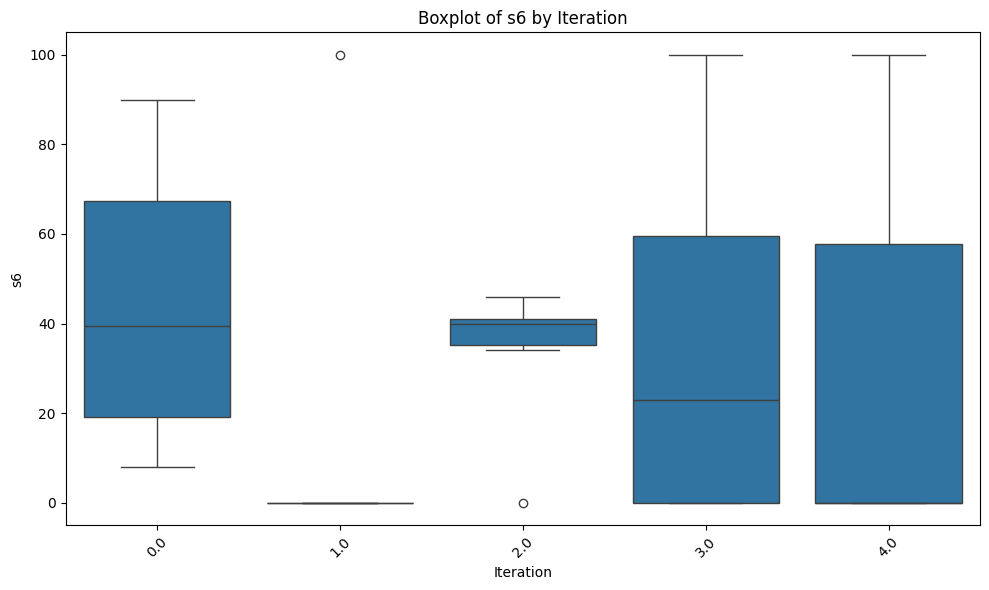

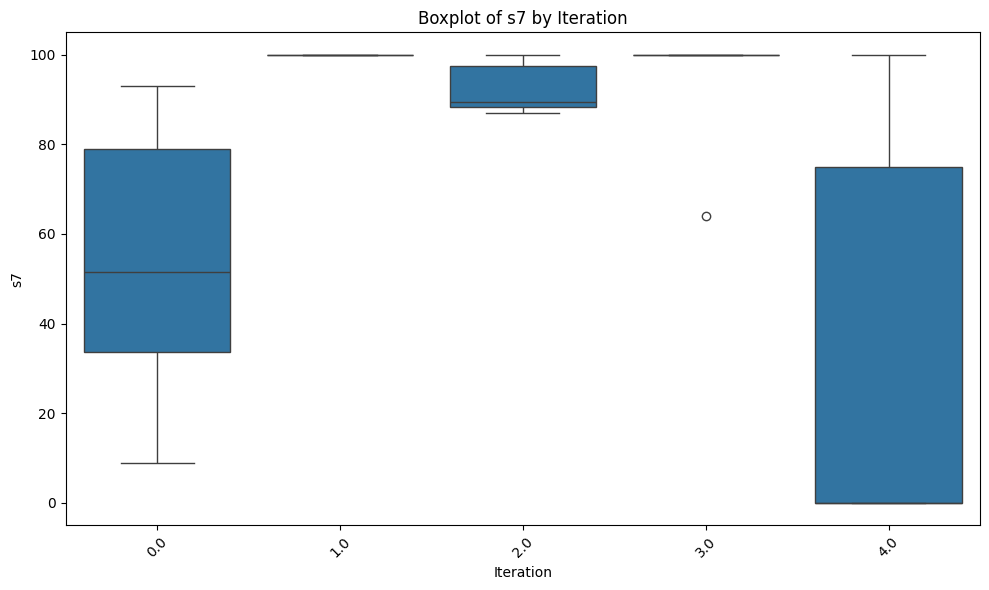

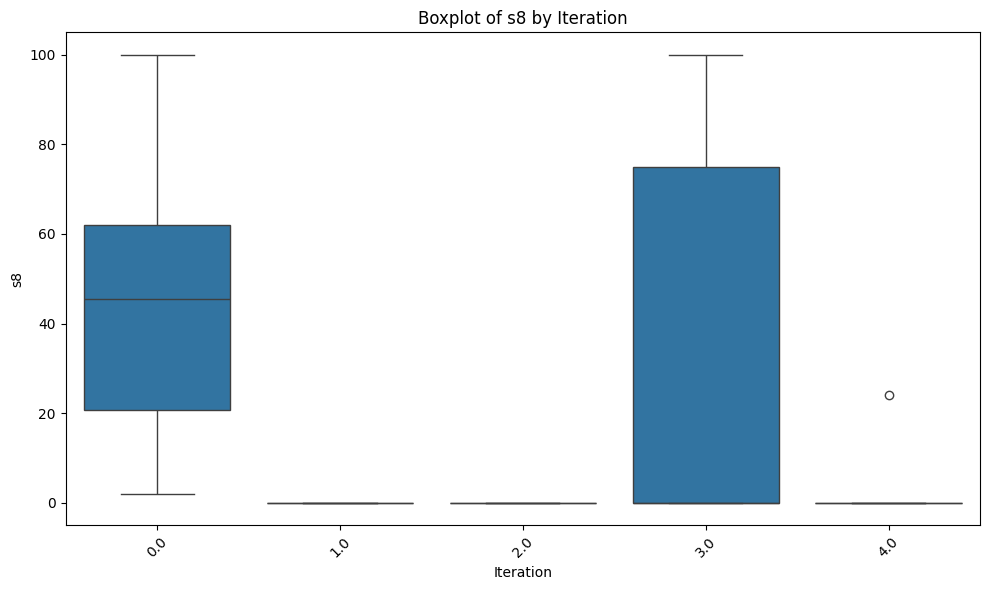

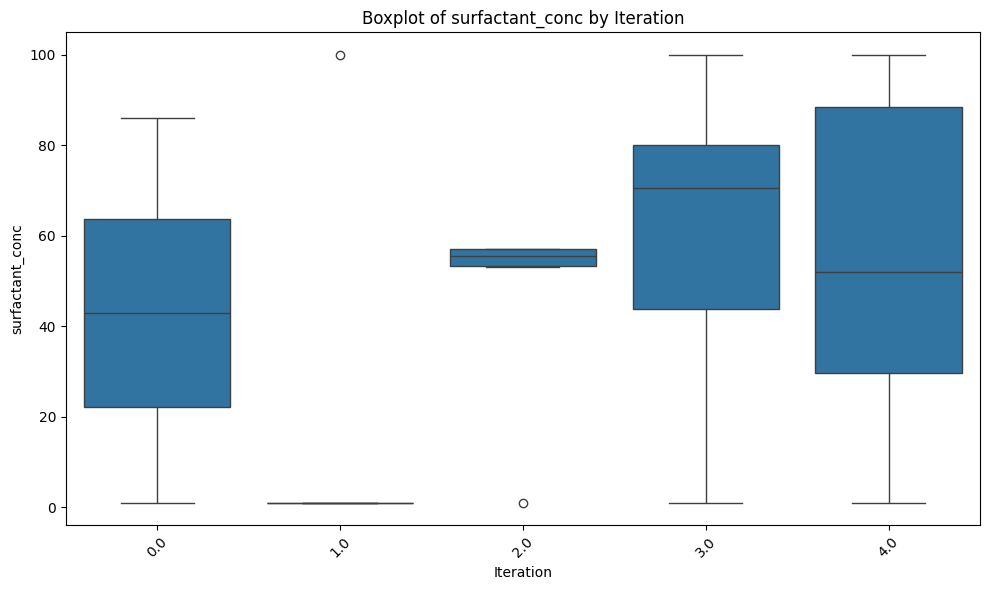

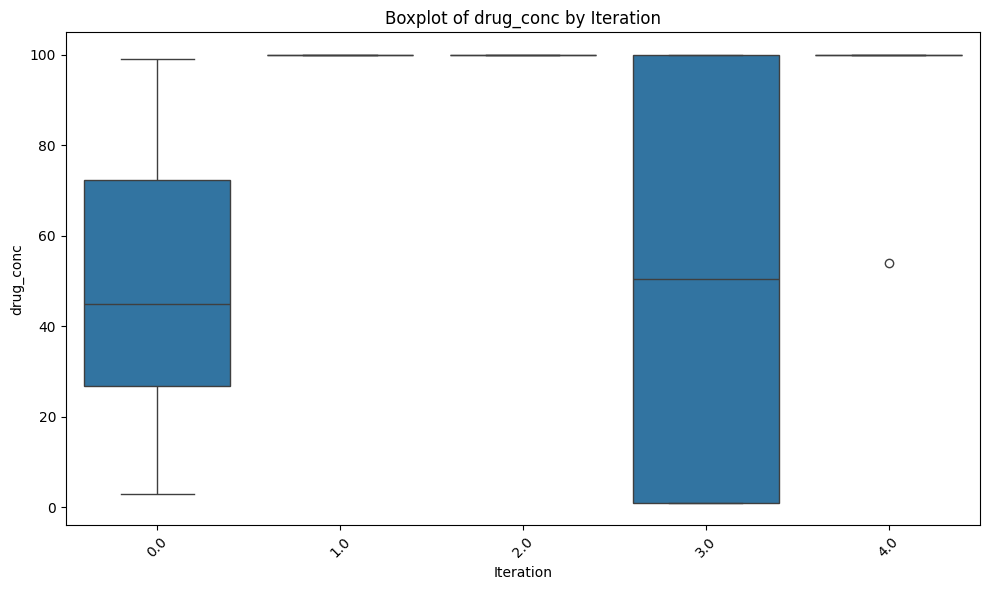

In [12]:
for col in params:

    plt.figure(figsize=(10, 6))
    sns.boxplot(x='Iteration', y=col, data=df)
    plt.title(f'Boxplot of {col} by Iteration')
    plt.xlabel('Iteration')
    plt.ylabel(col)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(f'boxplot_{col}.png')
    plt.show()

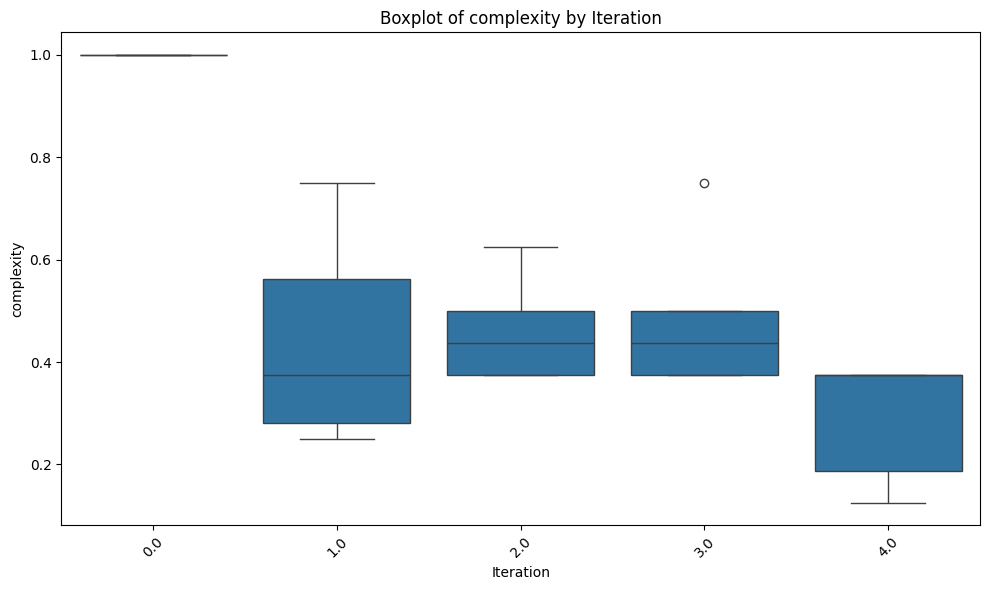

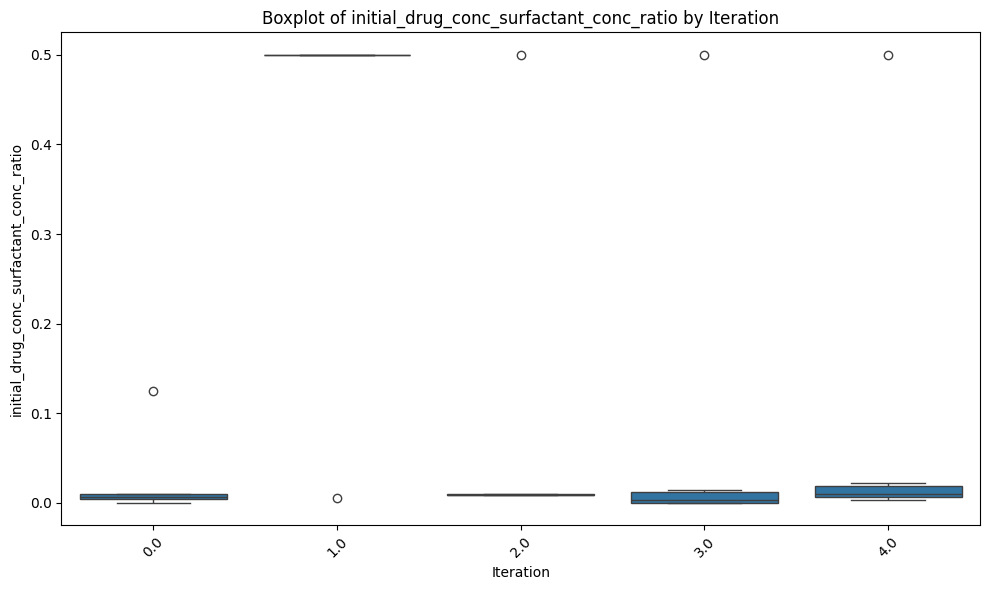

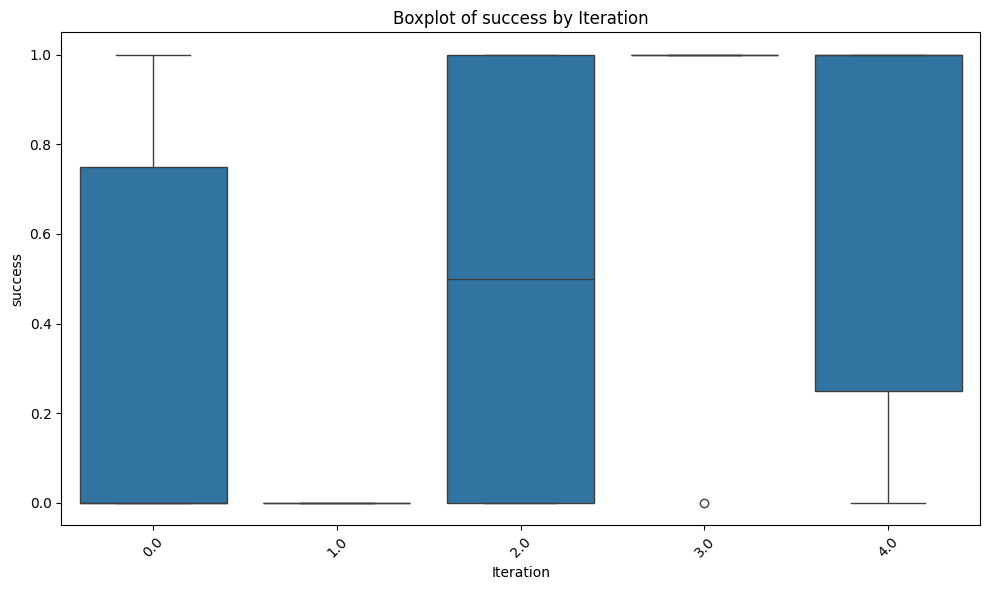

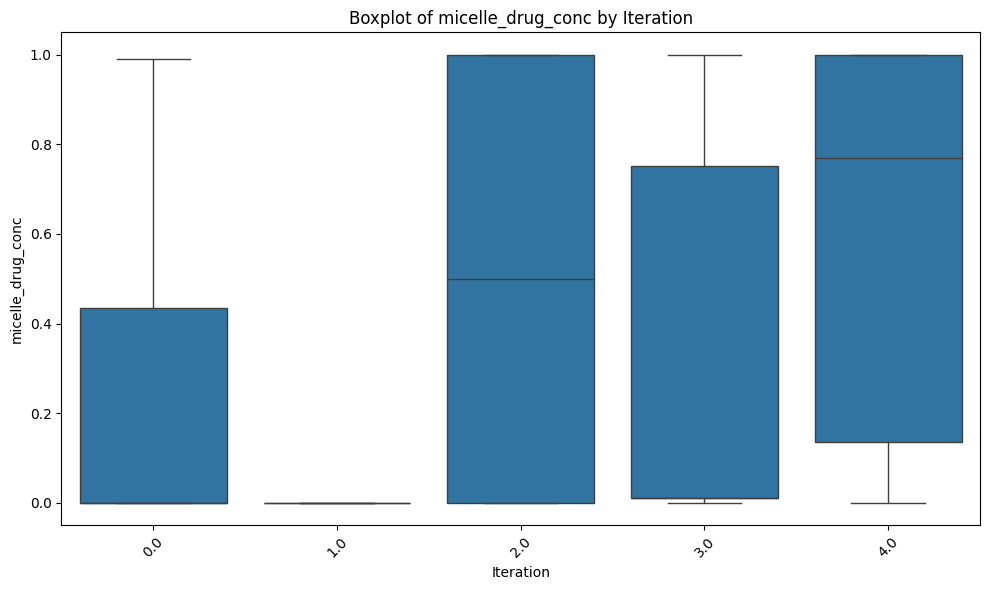

In [13]:
for col in objs:

    plt.figure(figsize=(10, 6))
    sns.boxplot(x='Iteration', y=col, data=df)
    plt.title(f'Boxplot of {col} by Iteration')
    plt.xlabel('Iteration')
    plt.ylabel(col)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(f'boxplot_{col}.png')
    plt.show()

In [24]:
import sys
sys.path.append('20250623/')
import helper_functions as hf



In [27]:
processed_df = hf.design_to_conc(df)
processed_df

,trial_index,surfactant_conc,drug_conc,s1,s2,s3,s4,s5,s6,s7,s8
0,0,43.0,19.25,6.142857,7.550595,6.398810,3.967262,12.285714,1.023810,1.279762,4.351190
1,1,17.5,0.50,3.166667,0.733333,2.533333,2.100000,1.433333,2.366667,1.833333,3.333333
2,2,9.0,8.25,1.285714,2.447802,0.098901,0.321429,0.543956,2.200549,0.717033,1.384615
3,3,33.5,14.50,0.523438,2.878906,6.194010,7.240885,5.496094,2.180990,7.589844,1.395833
4,4,0.5,6.00,0.025304,0.087045,0.098178,0.100202,0.058704,0.017206,0.048583,0.064777
5,5,25.5,24.75,6.059406,3.871287,2.356436,0.336634,0.420792,4.460396,7.826733,0.168317


In [ ]:
# 1. trial_index from df_design
df_design = pd.read_csv(design_file_path + 'i' + str(iteration) + '.csv')
results = pd.DataFrame()
results['trial_index'] = df_design['trial_index']

# 2. s1 to s12 from df_design
s_cols = [f's{i}' for i in range(1, number_of_surfactants+1)]
results[s_cols] = df_design[s_cols]

# 3. surfactant_conc and drug_conc from df_conc
results['surfactant_conc'] = df_conc['surfactant_conc']
results['drug_conc'] = df_conc['drug_conc']

# 4. Calculate initial drug concentration to surfactant concentration ratio
results['initial_drug_conc_surfactant_conc_ratio'] = results['drug_conc'] / results['surfactant_conc']

NameError: name 'df_conc' is not defined

In [ ]:
df -> normalized_df

df -> denormalized_df

denormalized_df -> pareto_frontier_symbol

denormalized_df -> Iteration hypervolume


SyntaxError: invalid syntax (2327839533.py, line 1)